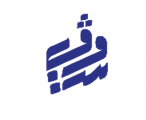
#  **Notebook d'Analyse de Qualité des Donnée(Data Quality)**
# **Sujet : E-Commerce Sougui Shop**

# Data Quality – Projet BI E-commerce

Objectif :
 1. Importer des données depuis différents formats (PDF, Excel, CSV, XML, etc.)
 2. Analyser la qualité des données selon plusieurs dimensions
 3. Générer des rapports et visualisations
 4. Proposer des corrections et améliorations

<span style="color:#B39DDB ">

## **Installation et configuration**
</span>

In [2]:
!pip install pandas numpy openpyxl xlrd odfpy pyxlsb pdfplumber lxml beautifulsoup4 matplotlib seaborn plotly missingno -q

<span style="color:#B39DDB ">

##  **Importation des bibliothèques**
</span>

In [4]:
# visualisations
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import missingno as msno

In [5]:
import pandas as pd
import numpy as np
import os
import json
import re
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

sns.set(style='whitegrid')

<span style="color:#B39DDB ">

##  **Chargement des fichiers**
</span>

In [6]:
def load_file(file_path, **kwargs):
    ext = os.path.splitext(file_path)[1].lower()

    if ext == '.xlsx':
        return pd.read_excel(file_path, engine='openpyxl', **kwargs)
    elif ext == '.xlsm':
        return pd.read_excel(file_path, engine='openpyxl', **kwargs)
    elif ext == '.xls':
        return pd.read_excel(file_path, engine='xlrd', **kwargs)
    elif ext == '.ods':
        return pd.read_excel(file_path, engine='odf', **kwargs)
    else:
        raise ValueError(f"Format Excel non supporté: {ext}")

<span style="color:#B39DDB ">

##  **ERP_Sougui_Model**
</span>

chargement du fichier

In [7]:
Df_ERP_Sougui_Model_Inventaire=load_file("C:/Users/eree/Desktop/wetransfer_artisanat-zip_2026-01-21_0929/artisanat/artisanat/Erp Sougui Model.xlsm",sheet_name="Inventaire")


<span style="color:#B39DDB ">

## **Vue d’ensemble des données**
</span>

In [8]:
Df_ERP_Sougui_Model_Inventaire.head()

,Référence Produit,Nom Produit,Stock Initial,Entrées,Sorties,Stock Actuel,Catégorie,Fournisseur,Prix achat,Prix unitaire
0,DS-001-SO,Diffuseur Sougui,0,0,0,0,Parfum d'ambiance,Sougui,NaN,30.0
1,BP-001-SO,Bougie Parfumée Sougui,0,0,0,0,Parfum d'ambiance,Sougui,NaN,30.0
2,BCM-001-KB,Bonbonniére Cuivre martelé 1,0,0,0,0,Articles en Cuivre,Karim Balleh,NaN,80.0
3,LPC-001-KB,Lance parfum cuivre martelé 1,0,0,0,0,Articles en Cuivre,Karim Balleh,NaN,40.0
4,MC-001-KB,Mathred Cuivre martelé 1,0,0,0,0,Articles en Cuivre,Karim Balleh,NaN,34.0


In [9]:
print(f"nombre colonnes : {Df_ERP_Sougui_Model_Inventaire.shape[1]}\nnombre des lignes {Df_ERP_Sougui_Model_Inventaire.shape[0]}")

nombre colonnes : 10
nombre des lignes 45


In [10]:
print(f"colonnes : {Df_ERP_Sougui_Model_Inventaire.columns.to_list()}")

colonnes : ['Référence Produit', 'Nom Produit', 'Stock Initial', 'Entrées', 'Sorties', 'Stock Actuel', 'Catégorie', 'Fournisseur', 'Prix achat', 'Prix unitaire']


In [11]:
print(Df_ERP_Sougui_Model_Inventaire.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Référence Produit  45 non-null     object 
 1   Nom Produit        45 non-null     object 
 2   Stock Initial      45 non-null     int64  
 3   Entrées            45 non-null     int64  
 4   Sorties            45 non-null     int64  
 5   Stock Actuel       45 non-null     int64  
 6   Catégorie          44 non-null     object 
 7   Fournisseur        45 non-null     object 
 8   Prix achat         4 non-null      float64
 9   Prix unitaire      44 non-null     float64
dtypes: float64(2), int64(4), object(4)
memory usage: 3.6+ KB
None


In [12]:
Df_ERP_Sougui_Model_Inventaire.describe().round(2)

,Stock Initial,Entrées,Sorties,Stock Actuel,Prix achat,Prix unitaire
count,45.00,45.0,45.0,45.00,4.00,44.00
mean,0.33,0.0,0.0,0.33,23.25,41.72
std,1.28,0.0,0.0,1.28,18.14,29.66
min,0.00,0.0,0.0,0.00,0.00,7.00
25%,0.00,0.0,0.0,0.00,13.50,19.50
50%,0.00,0.0,0.0,0.00,26.50,30.00
75%,0.00,0.0,0.0,0.00,36.25,60.00
max,6.00,0.0,0.0,6.00,40.00,125.00


<span style="color:#B39DDB ">

## **Unicité Metier**
</span>

In [13]:
Df_ERP_Sougui_Model_Inventaire["Référence Produit"].duplicated().sum()

np.int64(0)


<span style="color:pink">
on n'a aucun doublon de la refernce du produit donc donc l'unicité metier est assurée
</span>

<span style="color:#B39DDB ">

##  **Détection de doublons**
</span>

In [16]:
print('Doublons:', Df_ERP_Sougui_Model_Inventaire.duplicated().sum())

Doublons: 0


aucune ligne n est dupliquée deux fois dans ce tableau 


<span style="color:#B39DDB ">

##  **valeurs manquantes (NaN)**
</span>

In [14]:
def missing_values_table(df):
    mis_val = df.isnull().sum()
    mis_val_percent = 100 * df.isnull().sum() / len(df)
    mis_val_table = pd.DataFrame({
        'Missing Values': mis_val,
        '% of Total': mis_val_percent
    })
    mis_val_table = mis_val_table[mis_val_table['Missing Values'] > 0].sort_values('% of Total', ascending=False)
    return mis_val_table

In [15]:
print("Table_Name Table Missing Values:\n", missing_values_table(Df_ERP_Sougui_Model_Inventaire))

Table_Name Table Missing Values:
                Missing Values  % of Total
Prix achat                 41   91.111111
Catégorie                   1    2.222222
Prix unitaire               1    2.222222


<span style="color:#B39DDB ">
afficher ces pourcentages en histogramme
</span>

In [17]:
def afficherPoucentageNull(Df):    
# Trouver les colonnes avec valeurs nulles
    colonnes_nulls = {}
    for col in Df.columns:
        nb_nulls = Df[col].isnull().sum()
        if nb_nulls > 0:
            pourcentage = (nb_nulls / len(Df)) * 100
            colonnes_nulls[col] = pourcentage

    if colonnes_nulls:
        # Trier par pourcentage
        colonnes = list(colonnes_nulls.keys())
        pourcentages = list(colonnes_nulls.values())

    # Graphique
    plt.figure(figsize=(16, 6))
    bars = plt.bar(colonnes, pourcentages, color='pink',edgecolor='black')
    plt.xlabel('Colonnes')
    plt.ylabel('Pourcentage de valeurs nulles')

    plt.title('Valeurs nulles par colonne')
    plt.ylabel('% de valeurs nulles')
    plt.xticks(
        ticks=range(len(colonnes)),
        labels=colonnes,
        rotation=45,
        ha='right'
    )

    # ➕ Affichage des valeurs exactes sur les barres
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.2f}%',   # 2 décimales
            ha='center',
            va='bottom'
        )

    plt.tight_layout()
    plt.show()

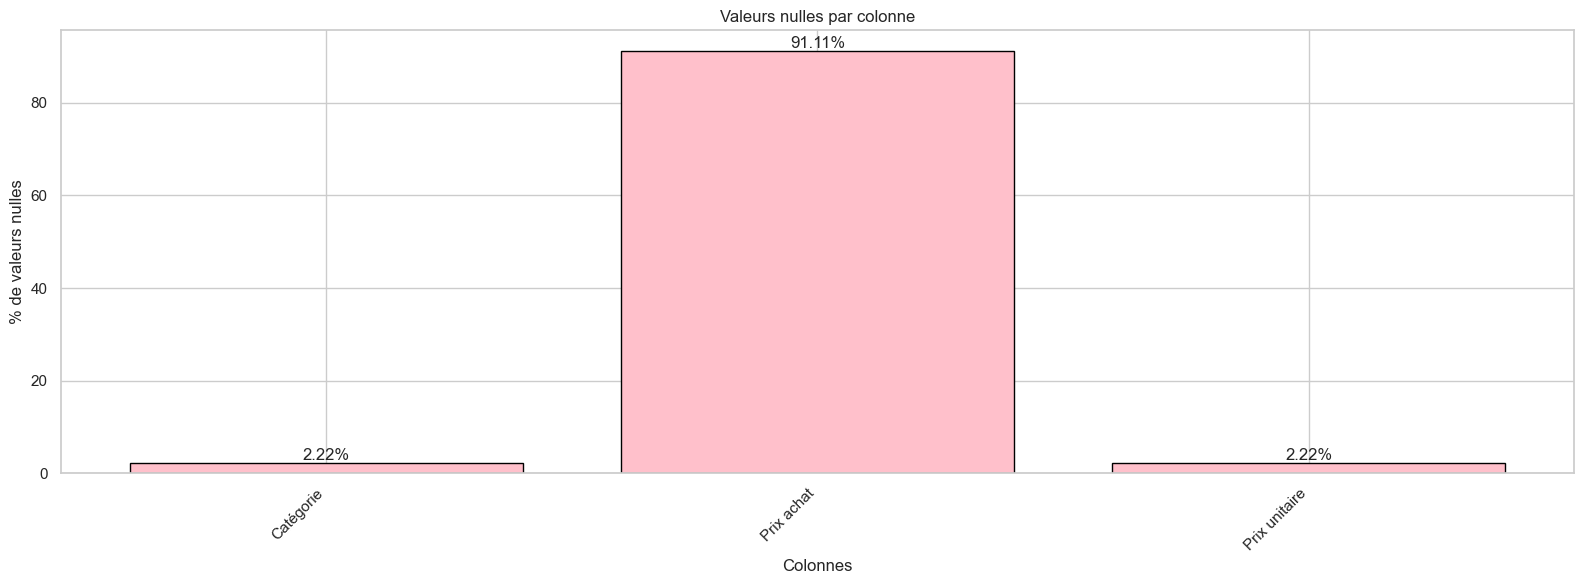

In [18]:
afficherPoucentageNull(Df_ERP_Sougui_Model_Inventaire)

<span style="color:pink">

La majorité des colonnes présentent **0 % de valeurs manquantes**
**Référence Produit, Nom Produit , Stock Initial , Entrées, Sorties ,Stock Actuel et Fournisseur**

Trois colonnes présentent des valeurs manquantes :

**Prix achat → ≈ 91 %** de valeurs sont manquantes on doit chercher ces prix peut etre dans les factures de ventes 


**Catégorie → ≈ 2 %** quelques produits n ont pas de categorie renseignée on peut chercher les categories par web scrapping ou dans d autres fichiers sinon on devra attribuer ces categories nous meme


**Prix unitaire → ≈ 2 %** quelques prix unitaires ne sont pas renseignés a chercher dans le web aussi 
</span>

<span style="color:#B39DDB ">

## **Analyse de complétude**
</span>

In [19]:
completude = (1 - Df_ERP_Sougui_Model_Inventaire.isnull().mean()) * 100
completude.sort_values()

Prix achat             8.888889
Catégorie             97.777778
Prix unitaire         97.777778
Référence Produit    100.000000
Entrées              100.000000
Sorties              100.000000
Stock Initial        100.000000
Nom Produit          100.000000
Fournisseur          100.000000
Stock Actuel         100.000000
dtype: float64

<span style="color:pink">
Prix achat est la colonne la plus critique en termes de complétude

Les autres colonnes sont globalement de très bonne qualité
</span>

<span style="color:#B39DDB ">

## **Score global Data Quality**
</span>

In [20]:
score_completude = 1 - Df_ERP_Sougui_Model_Inventaire.isnull().mean().mean()
print (score_completude)

0.9044444444444444


<span style="color:pink">
C’est un seul chiffre basé uniquement sur la complétude il donne une vision globale mais partielle on remarque donc que generalement la qualité des données est bonne en ce qui concerne la completude
</span>

<span style="color:#B39DDB ">

## **Tableau des Indicateurs de Data Quality (par dimension)**
</span>

In [21]:
score = {
    "completude": Df_ERP_Sougui_Model_Inventaire.notna().mean().mean(),
    "unicite": 1 - Df_ERP_Sougui_Model_Inventaire["Référence Produit"].duplicated().mean(),
    "validite_prix_unitaire": Df_ERP_Sougui_Model_Inventaire["Prix unitaire"].notna().mean()
}

pd.DataFrame(score, index=["DQ Score"]).T


,DQ Score
completude,0.904444
unicite,1.000000
validite_prix_unitaire,0.977778


<span style="color:pink">

3 dimensions différentes :


**Complétude**	Les données sont-elles remplies ? 0.9 tres bon score : elles sont presque complete : c est le meme score qu en haut

**Unicité**	Y a-t-il des doublons ? 1.00 toutes les references du produit sont unique

**Validité**	Les prix sont-ils présents ? : 0.97 donc la majorité dez prix sont presents 


**Chaque score : est normalisé entre 0 et 1 et est indépendant**


</span>


<span style="color:#B39DDB ">

## **Graphiques des valeurs aberrantes**
</span>

<span style="color:pink">

D apres **info**
les seules colonnes numeriques sont **Stock initial, Stock Actuel ,Entrées, Sorties, prix achat et prix unitaire** donc celles la sont les colonnes sur lesquelles il est possible de voir les valeurs abberantes 
</span>


describe montre clairement que pour **les colonnes entrées et sorties ont des moyennes nulles (mean=0) donc elles sont des colonnes entierement en zeros** donc il est non pertient de faire des boxplot pour ces colonnes


**il est necessaire de verifier si ces produits sont encore en vente ou non ou s ils seront disponibles prochainement ou voir si le stock est disponible dans le site web**

In [22]:
import pandas as pd

# df est ton DataFrame
total = len(Df_ERP_Sougui_Model_Inventaire)

# Nombre de valeurs manquantes et pourcentage
na_count = Df_ERP_Sougui_Model_Inventaire.isna().sum()
na_percent = (na_count / total * 100).round(2)

# Nombre de 0 et pourcentage (pour colonnes numériques)
zero_count = (Df_ERP_Sougui_Model_Inventaire==0).sum()
zero_percent = (zero_count / total * 100).round(2)

# Affichage
print("Valeurs manquantes par colonne :")
print(pd.DataFrame({'Count NaN': na_count, 'Percent NaN (%)': na_percent}))

print("\nValeurs 0 par colonne :")
print(pd.DataFrame({'Count 0': zero_count, 'Percent 0 (%)': zero_percent}))


Valeurs manquantes par colonne :
                   Count NaN  Percent NaN (%)
Référence Produit          0             0.00
Nom Produit                0             0.00
Stock Initial              0             0.00
Entrées                    0             0.00
Sorties                    0             0.00
Stock Actuel               0             0.00
Catégorie                  1             2.22
Fournisseur                0             0.00
Prix achat                41            91.11
Prix unitaire              1             2.22

Valeurs 0 par colonne :
                   Count 0  Percent 0 (%)
Référence Produit        0           0.00
Nom Produit              0           0.00
Stock Initial           42          93.33
Entrées                 45         100.00
Sorties                 45         100.00
Stock Actuel            42          93.33
Catégorie                0           0.00
Fournisseur              0           0.00
Prix achat               1           2.22
Prix unitaire   

<span style="color:gold">

la colonne **prix d achat a 91.11 de valeurs manquantes** : il est necessaire de completer ces colonnes peut etre a l aide dde l extraction des factures il n est pas necessaire de verifier kes valeurs aberrantes pour cette colonne


on a deja parlé **des entrées et sorties et de la necessitée de les verifier**


aussi le **stock initial et actuel** presentent toutes les deux **93.33% de valeurs nulles** donc il faut mettre a jour les stocks ou effacer ces produits de la liste si ils ne sont plus en vente il n est pas necessaire de voir les colonnes abberantes pour ces colonnes aussi 
</span>


il nous reste la colonne **prix unitaires** donc a verifier 


<span style="color:#B39DDB ">

## **Boxplot des Prix unitaires**
</span>

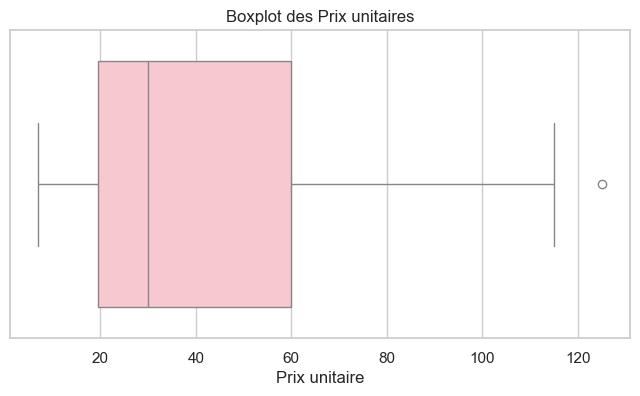

In [23]:
plt.figure(figsize=(8,4))
sns.boxplot(x=Df_ERP_Sougui_Model_Inventaire['Prix unitaire'], color='pink')
plt.title('Boxplot des Prix unitaires')
plt.show()


<span style="color:pink">

Médiane ≈ 30
**La moitié des prix unitaires est inférieure à ~30, l’autre moitié au-dessus.**

Q1 ≈ 20 et Q3 ≈ 60
**50 % des prix sont compris entre 20 et 60.**


il y a une Asymétrie : La moustache droite est beaucoup plus longue que la gauche
Distribution asymétrique à droite (skew positive)


**La majorité des produits ont des prix plutôt bas à moyens, mais quelques produits très chers** tirent la distribution vers le haut.

 
On observe un point isolé autour de 125: C’est une valeur aberrante (outlier)
un produit exceptionnel, premium ou une erreur à vérifier selon le contexte.
</span>


<span style="color:#B39DDB ">

## **Distribution des données**
</span>

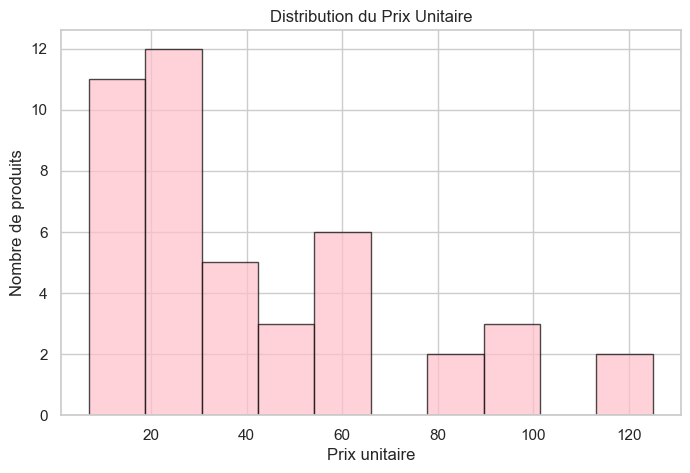

In [24]:

import matplotlib.pyplot as plt

# Histogramme du prix unitaire (valeurs non nulles)
plt.figure(figsize=(8, 5))
plt.hist(
    Df_ERP_Sougui_Model_Inventaire["Prix unitaire"].dropna(),
    bins=10,
    color='pink', edgecolor='black', alpha=0.7
)
plt.title("Distribution du Prix Unitaire")
plt.xlabel("Prix unitaire")
plt.ylabel("Nombre de produits")
plt.show()


<span style="color:pink">

***Concentration des prix***

La majorité des produits se situe dans **une plage de prix basse à moyenne, principalement entre 10 et 30.**

Cette zone concentre le plus grand nombre de produits, indiquant un positionnement majoritairement accessible.

***Asymétrie de la distribution***

La distribution est asymétrique à droite (right-skewed).

On observe une **queue à droite, avec quelques produits affichant des prix élevés.**

***Produits à prix élevés***

**Un nombre limité de produits présente des prix unitaires supérieurs à 60, allant jusqu’à environ 125.**
reflètent probablement des articles spécifiques ou premium.

***Il n’y a pas de pics multiples très marqués.***

La distribution suggère une structure de **prix relativement homogène, avec une majorité de produits dans une même gamme.**
</span>

<span style="color:#B39DDB ">

## **Problèmes identifiés**
</span>


<span style="color:#B39DDB ">

## **Recommandations**
</span>